# 1b — Text Cleaning & EDA

**Track owner:** Mithresh — Text Data Track

This notebook applies the text-data processing pipeline to the complete raw Adzuna
dataset (25,572 records from 91 source files).  It loads every raw JSON and JSONL
file, extracts the text fields, then cleans, normalises, removes stopwords,
lemmatises and runs skill-frequency EDA — using the same methodology that was
previously validated on the 8,489-record filtered dataset.

### Pipeline summary

| Step | Description |
|------|-------------|
| 1 | Load all raw records (legacy JSON + run JSONL) |
| 2 | Extract job_id, title, category_label, description |
| 3 | Deduplicate by job_id (keep first occurrence) |
| 4 | Preserve original description |
| 5 | Protect technical terms → clean HTML → normalise → lowercase |
| 6 | Remove stopwords (preserve negation words) |
| 7 | Lemmatise with spaCy |
| 8 | Calculate description word count |
| 9 | Skill-frequency EDA (35-skill vocabulary) |
| 10 | Category-wise analysis & visualisations |
| 11 | Validation & export |

In [1]:
# ── 1. Imports ─────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
import glob
import re
import os
from pathlib import Path
from collections import Counter

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ── 2. Dataset definition ──────────────────────────────────────────────

RAW_ROOT = Path("../data/raw/adzuna")

# Legacy JSON files (4 files, flat list of records)
LEGACY_GLOB = str(RAW_ROOT / "adzuna_*.json")

# Run JSONL files (records wrapped in {collection, raw})
RUN_GLOB = str(RAW_ROOT / "runs" / "*" / "records_*.jsonl")

# Output paths
OUTPUT_CSV = Path("../data/cleaned/postings_text.csv")
VIZ_DIR = Path("../reports/text_eda")
VIZ_DIR.mkdir(parents=True, exist_ok=True)

print("Legacy glob:", LEGACY_GLOB)
print("Run glob:", RUN_GLOB)
print("Output CSV:", OUTPUT_CSV)
print("Viz directory:", VIZ_DIR)

Legacy glob: ../data/raw/adzuna/adzuna_*.json
Run glob: ../data/raw/adzuna/runs/*/records_*.jsonl
Output CSV: ../data/cleaned/postings_text.csv
Viz directory: ../reports/text_eda


In [3]:
# ── 3. Load all raw records ────────────────────────────────────────────

rows = []

# 3a. Legacy JSON files (flat array under "results" key)
legacy_files = sorted(glob.glob(LEGACY_GLOB))
print(f"Legacy JSON files found: {len(legacy_files)}")

for fpath in legacy_files:
    with open(fpath) as f:
        data = json.load(f)
    results = data.get("results", data) if isinstance(data, dict) else data
    for r in results:
        cat = r.get("category", {})
        rows.append({
            "job_id": str(r.get("id", "")),
            "title": r.get("title", ""),
            "category_label": cat.get("label", "") if isinstance(cat, dict) else "",
            "category_tag": cat.get("tag", "") if isinstance(cat, dict) else "",
            "description": r.get("description", ""),
            "source_file": os.path.basename(fpath),
        })

legacy_count = len(rows)
print(f"Legacy records loaded: {legacy_count}")

# 3b. Run JSONL files (each line: {"collection": {...}, "raw": {...}})
run_files = sorted(glob.glob(RUN_GLOB))
print(f"\nRun JSONL files found: {len(run_files)}")

for fpath in run_files:
    with open(fpath) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            record = json.loads(line)
            raw = record.get("raw", record)
            cat = raw.get("category", {})
            rows.append({
                "job_id": str(raw.get("id", "")),
                "title": raw.get("title", ""),
                "category_label": cat.get("label", "") if isinstance(cat, dict) else "",
                "category_tag": cat.get("tag", "") if isinstance(cat, dict) else "",
                "description": raw.get("description", ""),
                "source_file": os.path.basename(fpath),
            })

run_count = len(rows) - legacy_count
print(f"Run records loaded: {run_count}")
print(f"\nTotal raw records loaded: {len(rows)}")

Legacy JSON files found: 4
Legacy records loaded: 2500

Run JSONL files found: 87


Run records loaded: 23072

Total raw records loaded: 25572


In [4]:
# ── 4. Dataset inspection ──────────────────────────────────────────────

df_raw = pd.DataFrame(rows)

print("Dataset shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
print("\nData types:")
print(df_raw.dtypes)
print("\nMissing values:")
print(df_raw.isnull().sum())
print("\nEmpty descriptions:", (df_raw["description"].fillna("").str.strip() == "").sum())
print("\nDuplicate job IDs:", df_raw["job_id"].duplicated().sum())
print("Unique job IDs:", df_raw["job_id"].nunique())
print("\nCategory distribution:")
print(df_raw["category_label"].value_counts())

Dataset shape: (25572, 6)

Columns: ['job_id', 'title', 'category_label', 'category_tag', 'description', 'source_file']

Data types:
job_id            object
title             object
category_label    object
category_tag      object
description       object
source_file       object
dtype: object

Missing values:
job_id            0
title             0
category_label    0
category_tag      0
description       0
source_file       0
dtype: int64

Empty descriptions: 0

Duplicate job IDs: 8909
Unique job IDs: 16663

Category distribution:
category_label
IT Jobs                             15660
Engineering Jobs                     3646
Accounting & Finance Jobs            2757
PR, Advertising & Marketing Jobs     1543
Creative & Design Jobs                539
Scientific & QA Jobs                  235
Consultancy Jobs                      234
Energy, Oil & Gas Jobs                215
Sales Jobs                            192
HR & Recruitment Jobs                 123
Trade & Construction Job

In [5]:
# ── 5. Deduplicate by job_id ───────────────────────────────────────────
# Many records appear in multiple source files (overlapping runs).
# Keep the first occurrence of each job_id.

before_dedup = len(df_raw)
df_raw = df_raw.drop_duplicates(subset="job_id", keep="first").reset_index(drop=True)
after_dedup = len(df_raw)

print(f"Records before dedup: {before_dedup:,}")
print(f"Records after dedup:  {after_dedup:,}")
print(f"Duplicates removed:   {before_dedup - after_dedup:,}")
print(f"\nDuplicate job IDs remaining: {df_raw['job_id'].duplicated().sum()}")

Records before dedup: 25,572
Records after dedup:  16,663
Duplicates removed:   8,909

Duplicate job IDs remaining: 0


In [6]:
# ── 6. Text-field selection ────────────────────────────────────────────

text_df = df_raw[["job_id", "title", "category_label", "description"]].copy()

# Rename category_label → category_name for output consistency
text_df.rename(columns={"category_label": "category_name"}, inplace=True)

# Drop rows with missing or empty descriptions
missing_desc = text_df["description"].isna() | (text_df["description"].str.strip() == "")
print(f"Missing/empty descriptions: {missing_desc.sum()}")

if missing_desc.sum() > 0:
    text_df = text_df[~missing_desc].reset_index(drop=True)
    print(f"Records after removing empty descriptions: {len(text_df):,}")

print(f"\nText dataset shape: {text_df.shape}")
print(f"Columns: {text_df.columns.tolist()}")
print(f"\nJob categories ({text_df['category_name'].nunique()}):")
print(text_df["category_name"].value_counts())

Missing/empty descriptions: 0

Text dataset shape: (16663, 4)
Columns: ['job_id', 'title', 'category_name', 'description']

Job categories (25):
category_name
IT Jobs                             10977
Engineering Jobs                     1988
PR, Advertising & Marketing Jobs     1152
Accounting & Finance Jobs            1016
Creative & Design Jobs                496
Scientific & QA Jobs                  182
Sales Jobs                            159
Consultancy Jobs                      148
Energy, Oil & Gas Jobs                120
HR & Recruitment Jobs                  89
Trade & Construction Jobs              86
Manufacturing Jobs                     37
Teaching Jobs                          29
Admin Jobs                             28
Logistics & Warehouse Jobs             27
Retail Jobs                            27
Healthcare & Nursing Jobs              25
Customer Services Jobs                 21
Legal Jobs                             10
Maintenance Jobs                       10
G

In [7]:
# ── 7. Preserve original text ──────────────────────────────────────────

text_df["description_original"] = text_df["description"]
text_df["description_clean"] = text_df["description"]

print("Original description preserved:", text_df["description_original"].notna().all())
print("Clean description column created:", "description_clean" in text_df.columns)
print("Current shape:", text_df.shape)

Original description preserved: True
Clean description column created: True
Current shape: (16663, 6)


In [8]:
# ── 8. Check for HTML tags ─────────────────────────────────────────────

html_pattern = r"<[^>]+>"

html_count = text_df["description_clean"].str.contains(
    html_pattern, regex=True, na=False
).sum()

print(f"Descriptions containing HTML tags: {html_count}")
print(f"Total descriptions: {len(text_df):,}")
print(f"Percentage containing HTML: {html_count / len(text_df) * 100:.2f}%")

Descriptions containing HTML tags: 0
Total descriptions: 16,663
Percentage containing HTML: 0.00%


In [9]:
# ── 9. Text normalisation ──────────────────────────────────────────────
# Technical symbols are protected during cleaning and restored afterward.

PROTECTED_TERMS = {
    "c++": "cplusplus",
    "c#": "csharp",
    ".net": "dotnet",
    "node.js": "nodejs",
    "react.js": "reactjs",
    "next.js": "nextjs",
    "vue.js": "vuejs",
    "angular.js": "angularjs",
    "asp.net": "aspnet",
    "power bi": "powerbi",
    "sql server": "sqlserver",
    "nosql": "nosql",
    "ci/cd": "cicd",
    "github": "github",
    "gitlab": "gitlab",
    "aws": "aws",
    "azure": "azure",
    "gcp": "gcp"
}

RESTORE_TERMS = {v: k for k, v in PROTECTED_TERMS.items()}

def protect_terms(text):
    text = str(text).lower()
    for term, placeholder in sorted(
        PROTECTED_TERMS.items(), key=lambda x: len(x[0]), reverse=True
    ):
        text = re.sub(
            r"(?<!\w)" + re.escape(term) + r"(?!\w)", placeholder, text
        )
    return text

def normalize_text(text):
    text = protect_terms(text)
    text = re.sub(r"<[^>]+>", " ", text)           # strip HTML tags
    text = re.sub(r"[^a-z0-9_\s]", " ", text)     # remove special chars
    text = re.sub(r"\s+", " ", text).strip()       # normalise whitespace

    for placeholder, original_term in RESTORE_TERMS.items():
        text = re.sub(
            r"(?<!\w)" + re.escape(placeholder) + r"(?!\w)",
            original_term, text
        )
    return text

text_df["description_clean"] = text_df["description"].apply(normalize_text)

# Drop records whose description becomes empty after normalisation
# (non-English postings — Punjabi, Odia, Urdu — contain no ASCII text)
empty_after_clean = text_df["description_clean"].str.strip() == ""
if empty_after_clean.sum() > 0:
    print(f"Dropping {empty_after_clean.sum()} non-English records with empty normalised text.")
    text_df = text_df[~empty_after_clean].reset_index(drop=True)

print("Text normalisation completed.")
print(f"Records remaining: {len(text_df):,}")
print(f"\nOriginal description (first record):")
print(text_df["description_original"].iloc[0][:500])
print(f"\nCleaned description (first record):")
print(text_df["description_clean"].iloc[0][:500])

Dropping 3 non-English records with empty normalised text.
Text normalisation completed.
Records remaining: 16,660

Original description (first record):
This job is with Kyndryl, an inclusive employer and a member of myGwork – the largest global platform for the LGBTQ business community. Please do not contact the recruiter directly. Who We Are At Kyndryl, we run and reimagine the mission-critical technology systems that drive advantage for the world's leading businesses. We are at the heart of progress; with proven expertise and a continuous flow of AI-powered insight, enabling smarter decisions, faster innovation, and a lasting competitive edg…

Cleaned description (first record):
this job is with kyndryl an inclusive employer and a member of mygwork the largest global platform for the lgbtq business community please do not contact the recruiter directly who we are at kyndryl we run and reimagine the mission critical technology systems that drive advantage for the world s leading busi

In [10]:
# ── 10. Validate normalisation ─────────────────────────────────────────

print("Original and cleaned descriptions stored separately:",
      "description_original" in text_df.columns and
      "description_clean" in text_df.columns)

# Check lowercase
def check_lowercase(text):
    letters = [c for c in str(text) if c.isalpha()]
    return all(c.islower() for c in letters) if letters else True

lowercase_ok = text_df["description_clean"].apply(check_lowercase)
print(f"Descriptions fully lowercase: {lowercase_ok.sum():,} / {len(text_df):,}")
print(f"Not fully lowercase: {(~lowercase_ok).sum()}")

# Check multiple spaces
multi_spaces = text_df["description_clean"].str.contains(
    r"\s{2,}", regex=True, na=False
).sum()
print(f"Descriptions with multiple consecutive spaces: {multi_spaces}")

# Check missing
print(f"Missing cleaned descriptions: {text_df['description_clean'].isna().sum()}")

Original and cleaned descriptions stored separately: True


Descriptions fully lowercase: 16,660 / 16,660
Not fully lowercase: 0


Descriptions with multiple consecutive spaces: 0
Missing cleaned descriptions: 0


In [11]:
# ── 11. Stopword removal ───────────────────────────────────────────────

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

# Preserve important negation words
protected_words = {"no", "not", "nor", "never", "neither", "without"}
custom_stop_words = stop_words - protected_words

print(f"Original stopwords: {len(stop_words)}")
print(f"Protected words: {sorted(protected_words)}")
print(f"Stopwords used for removal: {len(custom_stop_words)}")

Original stopwords: 198
Protected words: ['neither', 'never', 'no', 'nor', 'not', 'without']
Stopwords used for removal: 195


In [12]:
# ── 12. Apply stopword removal ─────────────────────────────────────────

def remove_stopwords(text):
    words = str(text).split()
    return " ".join(w for w in words if w not in custom_stop_words)

text_df["description_nostopwords"] = text_df["description_clean"].apply(remove_stopwords)

print("Stopword removal completed.")

# Validate on first record
sample_orig = text_df["description_clean"].iloc[0]
sample_nostop = text_df["description_nostopwords"].iloc[0]
print(f"\nOriginal word count: {len(sample_orig.split())}")
print(f"After stopword removal: {len(sample_nostop.split())}")
print(f"\nProtected-word check:")
for word in sorted(protected_words):
    if word in sample_orig.split():
        status = "preserved" if word in sample_nostop.split() else "REMOVED"
        print(f"  {word}: {status}")

Stopword removal completed.

Original word count: 80
After stopword removal: 46

Protected-word check:
  not: preserved


In [13]:
# ── 13. Lemmatisation ──────────────────────────────────────────────────

import spacy

nlp = spacy.load("en_core_web_sm")

# Increase max_length for safety with large descriptions
nlp.max_length = 2_000_000

def lemmatize_text(text):
    doc = nlp(str(text))
    return " ".join(token.lemma_ for token in doc if not token.is_space)

# Use nlp.pipe for efficient batch processing on large dataset
print(f"Lemmatising {len(text_df):,} descriptions (this may take a few minutes)...")

lemmatized = []
batch_size = 500
texts = text_df["description_clean"].tolist()

for i in range(0, len(texts), batch_size):
    batch = texts[i:i + batch_size]
    for doc in nlp.pipe(batch, batch_size=batch_size, n_process=1):
        lemmatized.append(" ".join(token.lemma_ for token in doc if not token.is_space))
    if (i + batch_size) % 5000 == 0 or i + batch_size >= len(texts):
        print(f"  Processed {min(i + batch_size, len(texts)):,} / {len(texts):,}")

text_df["description_lemmatized"] = lemmatized

print(f"\nLemmatisation completed.")
print(f"Sample lemmatised description:")
print(text_df["description_lemmatized"].iloc[0][:500])

Lemmatising 16,660 descriptions (this may take a few minutes)...


  Processed 5,000 / 16,660


  Processed 10,000 / 16,660


  Processed 15,000 / 16,660


  Processed 16,660 / 16,660

Lemmatisation completed.
Sample lemmatised description:
this job be with kyndryl an inclusive employer and a member of mygwork the large global platform for the lgbtq business community please do not contact the recruiter directly who we be at kyndryl we run and reimagine the mission critical technology system that drive advantage for the world s lead business we be at the heart of progress with prove expertise and a continuous flow of ai power insight enable smart decision fast innovation and a last competitive edg


In [14]:
# ── 14. Validate lemmatisation ─────────────────────────────────────────

print(f"Total records: {len(text_df):,}")
print(f"Missing lemmatised descriptions: {text_df['description_lemmatized'].isna().sum()}")
print(f"Empty lemmatised descriptions: {(text_df['description_lemmatized'].fillna('').str.strip() == '').sum()}")
print(f"\nAverage original word count: {text_df['description_original'].str.split().str.len().mean():.1f}")
print(f"Average lemmatised word count: {text_df['description_lemmatized'].str.split().str.len().mean():.1f}")

Total records: 16,660
Missing lemmatised descriptions: 0
Empty lemmatised descriptions: 0

Average original word count: 71.9
Average lemmatised word count: 73.3


In [15]:
# ── 15. Description word count ─────────────────────────────────────────

text_df["description_word_count"] = (
    text_df["description_original"]
    .fillna("")
    .str.split()
    .str.len()
)

print("Description word count calculated.")
print("\nSummary statistics:")
print(text_df["description_word_count"].describe())

Description word count calculated.

Summary statistics:


count    16660.000000
mean        71.934994
std          7.324400
min         12.000000
25%         68.000000
50%         72.000000
75%         77.000000
max        111.000000
Name: description_word_count, dtype: float64


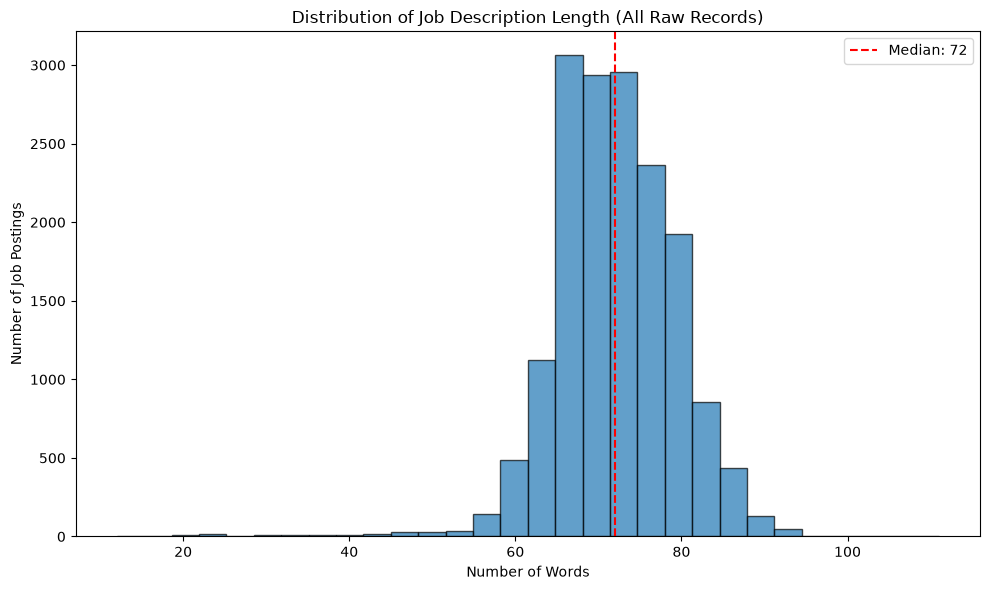

Saved: description_length_distribution.png


In [16]:
# ── 16. Description length distribution ────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(text_df["description_word_count"], bins=30, edgecolor="black", alpha=0.7)
ax.set_xlabel("Number of Words")
ax.set_ylabel("Number of Job Postings")
ax.set_title("Distribution of Job Description Length (All Raw Records)")
ax.axvline(
    text_df["description_word_count"].median(),
    color="red", linestyle="--", label=f'Median: {text_df["description_word_count"].median():.0f}'
)
ax.legend()
plt.tight_layout()
plt.savefig(str(VIZ_DIR / "description_length_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: description_length_distribution.png")

### Description Length — Interpretation

The distribution shows the word count of the original (unprocessed) descriptions
across all unique raw records. Because the Adzuna API returns truncated
~500-character snippets, most descriptions cluster in a narrow range. Outliers
may indicate records where the API returned shorter snippets or records with
very brief postings.